<center style="white-space: nowrap;">
  <img src="./logo.png" width="200" style="display: inline-block;">
    <img src="./cat.png" width="180" style="display: inline-block;">
</center>

<center>
  <b>Department of Physics - Amirkabir University of Technology<br>
  Nima Yadollahi - PolyhaQ (Summer 2026) </b>
</center>

##### Main refrence: section 7.6
<center style="white-space: nowrap;">
    <img src="./ref.jpg" width="200" style="display: inline-block;">
</center>

-----------------------------------------------------------------------------------

My github acc: [![GitHub](https://img.shields.io/badge/GitHub-100000?style=for-the-badge&logo=github&logoColor=white)](https://github.com/nimayadollahi)

# Grover's Quantum Search Algorithm Implementation
------------------------------------------------------------------------------------------------
<br>

* **Suppose we have to find someone's phone number from an alphabetically ordered list:**

<center style="white-space: nowrap;">
    <img src="./Table.png" width="300" style="display: inline-block;">
    <img src="./Wong.jpg" width="600" style="display: inline-block;">
</center>

<br>

- <strong> <a href="https://en.wikipedia.org/wiki/Binary_search#:~:text=Binary%20search%20compares%20the%20target,the%20target%20value%20is%20found.">Binary Search:</a> </strong> compares the target value to the middle element of the array. If they are not equal, the half in which the target cannot lie is eliminated and the search continues on the remaining half, again taking the middle element to compare to the target value, and repeating this until the target value is found.
- If the number of entries is $N$, it takes at most $\log_2(N)$ steps.

<br>

* The inverse problem, however, is harder to do. Given a phone number, say 299-7924, finding the name it corresponds to is harder since the numbers are unsorted.
* <strong> <a href="https://en.wikipedia.org/wiki/Brute-force_search">Brute-force Search:</a> </strong> systematically checking all possible candidates for whether or not each candidate satisfies the problem's statement.
* The complexity of this problem is $O(N)$ which means a classical computer needs $O(N)$ queries to solve it.

#### A quantum computer can solve the brute-force searching problem using only $O(\sqrt N)$ queries using Grover’s algorithm (**quadratic speedup**).

## Grover's Algorithm as a Quantum Walk

#### Grover's search can be interpreted as a discrete-time quantum walk on a complete graph with self-loops. In this framework:

* The search space of N elements corresponds to the N vertices of a complete graph

## Classical vs Quantum Oracle:
------------------------------------------------------------------------------------------------

##### 1. The oracle changes completely depending on the problem. #####

<strong> Classical oracle) </strong> is a black-box operation that performs a specific computational task without revealing how it works internally.

* $f: \{0,1\}^n \rightarrow \{0,1\}^m$

<strong> Quantum oracle) </strong> In quantum mechanics, all operations must be reversible and, for standard quantum computing, unitary.

*  We can turn it into a reversible circuit by XORing its output with an extra bit:

<center style="white-space: nowrap;">
    <img src="./oracle.png" width="500" style="display: inline-block;">
</center>

*  The quantum oracle is a unitary gate $U_f$ acting on two registers: $$U_f |x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$$

    where:
- $|x\rangle$ is the input (query) register
- $|y\rangle$ is the auxiliary (ancilla) register  
- $\oplus$ denotes bitwise addition modulo 2 (XOR)

## Phase oracle:
------------------------------------------------------------------------------------------------
* If we query a quantum oracle the standard way described above, the input qubit
$|x\rangle$ is unchanged while the answer qubit $|y\rangle$ becomes $|y \oplus f(x)\rangle$.

* There is a way to query the quantum oracle, however, that causes the answer qubit |y⟩ to be unchanged while multiplying $|x\rangle$ by a phase.

* <strong> Why? </strong> Storing the answer in the ancilla qubit forces us to measure it (destroying quantum parallelism), while encoding it in the phase preserves superposition for interference.

<center style="white-space: nowrap;">
    <img src="./Kickback.jpg" width="600" style="display: inline-block;">
</center>

* The oracle in this problem is a black box, simulated using quantum gates, that maps each name to its corresponding phone number. The oracle flips (marks) the phase of the quantum state based on the comparison result, where f(name)=1 if the phone number matches the target and f(name)=0 otherwise. Thus, if a match is found, the state receives a negative phase (is marked), otherwise it remains positive, and this phase flip is what enables Grover's amplitude amplification.


* Common misconception: The Oracle already knows the answer, so the problem is already solved.

* Correct perspective: The Oracle can only verify whether a proposed candidate solution is correct.

##### For Grover's algorithm to be applicable to a problem, you typically need a classical oracle f(x) that can determine, for any input x, whether it is a valid solution: 

\begin{cases}
1 & \text{if } x \text{ is a valid solution} \\
0 & \text{otherwise}
\end{cases}

##### The oracle is often assumed to be available as a black box, and the analysis focuses on counting how many times it must be queried.

<center style="white-space: nowrap;">
    <img src="./grover.png" width="500" style="display: inline-block;">
</center>

# Libraries

In [9]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [62]:
target = '001'
target = target[::-1]
target

'100'

In [11]:
for i, bit in enumerate(target):
    print(i,bit)

0 1
1 0
2 0


In [64]:
flip_qubits = [i for i, bit in enumerate(target) if bit == '0']
flip_qubits

[1, 2]

In [66]:
def phase_oracle(marked_states: list[str]) -> QuantumCircuit:

    n = len(marked_states[0])
    qc = QuantumCircuit(n, name='Phase oracle')

    # Bitstrings validatation & remove duplicates
    if not marked_states:
        raise ValueError("marked_states cannot be empty")
    
    for state in marked_states:
        assert len(state) == n, f"State {state} length {len(state)} != {n}"
        assert all(c in '01' for c in state), f"State {state} contains non-binary characters"

    unique_states = []
    for state in marked_states:
        if state not in unique_states:
            unique_states.append(state)
        
    # Special case: All states are marked (Grover doesn't make sense)
    if len(unique_states) == 2**n:
        raise ValueError("All states are marked; Grover search is not meaningful.")
    
    # Build oracle for each marked state
    for target in unique_states:

        target = target[::-1] # Because Qiskit qubit ordering and binary string ordering are opposite
    
        flip_qubits = [i for i, bit in enumerate(target) if bit == '0']
        
        if flip_qubits:
            qc.x(flip_qubits)
        
        # Multi-controlled Z
        if n == 1:
            qc.z(0)
        else:
            qc.h(n - 1)                      
            qc.mcx(list(range(n - 1)), n - 1)
            qc.h(n - 1)                     
        
        # Undo the flips to restore original basis
        if flip_qubits:
            qc.x(flip_qubits)
    
    return qc

Phase_oracle circuit for target |001⟩:


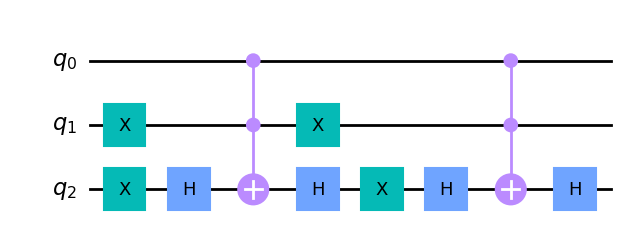

In [70]:
oracle_demo = phase_oracle(['001','111'])
print('Phase_oracle circuit for target |001⟩:')
oracle_demo.draw(output='mpl', style='clifford')

<center style="white-space: nowrap;">
    <img src="./r1.jpg" width="700" style="display: inline-block;">
</center>

<div style="display: flex; align-items: flex-start;">
  
  <div style="margin-right: 50px;">
    <img src="./g1.jpg" width="400" style="display: block;">
  </div>

  <div>
    <div style="margin-bottom: 10px;">
      <img src="./MCZ.png" width="400" style="display: block;">
    </div>
    <div style="margin-top: 10px;">
      <img src="./truth_table.png" width="400" style="display: block;">
    </div>
  </div>
  
</div>

------------------------------------------------------------------------------------------------

In [72]:
def diffuser(n: int) -> QuantumCircuit:

    qc = QuantumCircuit(n, name='Diffuser')
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    
    return qc

Diffusion operator for n=3:


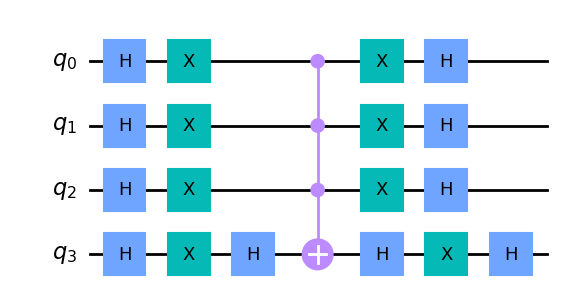

In [76]:
diffuser_demo = diffuser(4)
print('Diffusion operator for n=3:')
diffuser_demo.draw(output='mpl', style='clifford')

<center style="white-space: nowrap;">
    <img src="./r2.jpg" width="650" style="display: inline-block;">
    <img src="./g2.jpg" width="300" style="display: inline-block;">
</center>

--------------------------------------------------------------------------------

* #### N = total search space
* #### M = number of marked solutions
* #### Best performance when M ≪ N

<center style="white-space: nowrap;">
    <img src="./iteration.png" width="300" style="display: inline-block;">
</center>

In [78]:
def optimal_iterations(n, M):
    N = 2**n
    return max(1, int(np.floor(np.pi/4 * np.sqrt(N/M))))

In [80]:
def grover_circuit(
    n: int,
    marked_states: list[str],
    iterations: int | None = None,
    barriers: bool = True,
) -> tuple[QuantumCircuit, int]:

    k = iterations if iterations is not None else optimal_iterations(n, len(marked_states))

    qr = QuantumRegister(n, 'q')
    cr = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(qr, cr)

    # Uniform superposition
    qc.h(range(n))
    if barriers:
        qc.barrier(label='init')

    # Grover iterations
    oracle_gate   = phase_oracle(marked_states).to_gate()
    diffuser_gate = diffuser(n).to_gate()

    for i in range(k):
        qc.append(oracle_gate,   range(n))
        qc.append(diffuser_gate, range(n))
        if barriers and i < k - 1:
            qc.barrier(label=f'iter {i+1}')

    # Measure
    if barriers:
        qc.barrier(label='meas')
    qc.measure(range(n), range(n))

    return qc, k

Grover circuit (n=3, target=101, k=2 iterations):


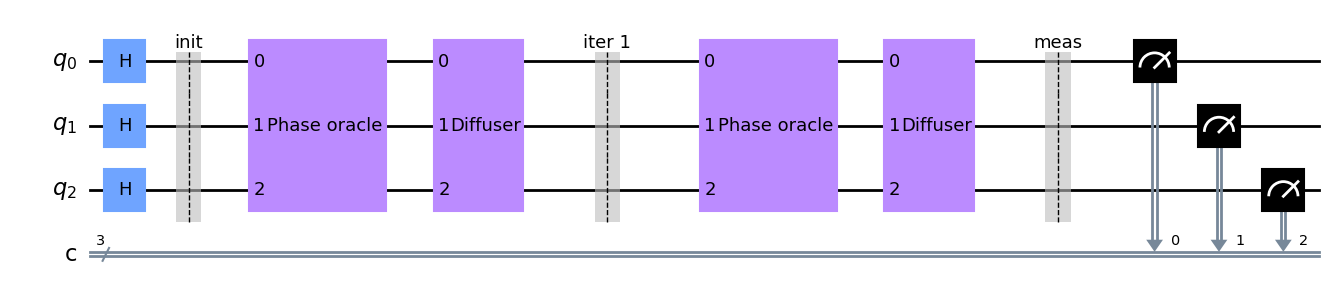


Circuit depth : 6
Gate count    : OrderedDict({'h': 3, 'barrier': 3, 'measure': 3, 'Phase oracle': 2, 'Diffuser': 2})


In [82]:
demo_circ, demo_k = grover_circuit(3, ['001'])
print(f'Grover circuit (n=3, target=101, k={demo_k} iterations):')

display(demo_circ.draw(output='mpl', style='clifford'))

print(f'\nCircuit depth : {demo_circ.depth()}')
print(f'Gate count    : {demo_circ.count_ops()}')

### Simulation setup: ###

In [84]:
SHOTS = 8000
SIM   = AerSimulator()

print(f'  Simulator : {SIM.name}')
print(f'  Shots     : {SHOTS}')

  Simulator : aer_simulator
  Shots     : 8000


In [86]:
def run_grover(
    n: int,
    marked_states: list[str],
    shots: int = SHOTS,
    show_circuit: bool = True,
) -> dict:

    # Build circuit
    circ, k = grover_circuit(n, marked_states)

    if show_circuit:
        print("Circuit:")
        print(circ.draw(output="text", fold=120))

    # Run
    compiled = transpile(circ, SIM)
    counts = SIM.run(compiled, shots=shots).result().get_counts()

    # Statistics
    total = sum(counts.values())

    marked_counts = {s: counts.get(s, 0) for s in marked_states}

    marked_total = sum(marked_counts.values())

    success_prob = marked_total / total
    classical_prob = len(marked_states) / (2 ** n)

    speedup = (success_prob / classical_prob if classical_prob > 0 else float("inf"))

    # Summary 
    print("\n" + "─" * 52)
    print(f"  Qubits            : {n}")
    print(f"  Search space N    : {2**n}")
    print(f"  Solutions M       : {len(marked_states)} → {marked_states}")
    print(f"  Grover iterations : {k}")
    print(f"  Shots             : {shots}")
    print("─" * 52)
    print(
        f"  Success rate      : "
        f"{success_prob:.2%} ({marked_total}/{total})"
    )
    print(f"  Classical baseline: {classical_prob:.2%}")
    print(f"  Effective speedup : {speedup:.1f}×")
    print("─" * 52)

    print("  Top measurement outcomes:")

    for state, cnt in sorted(counts.items(),key=lambda x: x[1],reverse=True):
        marker = "Answer" if state in marked_states else ""
        bar = "#" * int(50 * cnt / shots)

        print(
            f"    |{state}⟩ "
            f"{bar:<50s} "
            f"{cnt:5d} "
            f"({cnt/shots:.1%})"
            f"{marker}"
        )

    # Custom histogram 
    all_states = [format(i, f"0{n}b") for i in range(2 ** n)]

    values = [counts.get(state, 0) for state in all_states]

    colors = ["red" if state in marked_states else "blue" for state in all_states]

    fig, ax = plt.subplots(figsize=(max(10, len(all_states) * 0.8), 6))

    bars = ax.bar(all_states,values,color=colors)

    ax.set_title(f"Grover results | n={n}, "f"targets={marked_states}, k={k}")

    ax.set_xlabel("Basis state")
    ax.set_ylabel("Count")

    ax.grid(axis="y",linestyle="--",alpha=0.5)

    ymax = max(values) if values else 1

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + ymax * 0.01,str(value),ha="center",va="bottom",fontsize=10,)

    red_patch = mpatches.Patch(
        color="red",
        label="Marked state")

    blue_patch = mpatches.Patch(color="blue",label="Non-marked")

    ax.legend(handles=[red_patch, blue_patch])

    plt.tight_layout()
    plt.show()

    return {
        "counts": counts,
        "circuit": circ,
        "iterations": k,
        "success_prob": success_prob,
    }

### Simulation results: ###

Example 1: n=3, N=8, M=2
Circuit:
     ┌───┐ init ┌───────────────┐┌───────────┐ meas ┌─┐      
q_0: ┤ H ├──░───┤0              ├┤0          ├──░───┤M├──────
     ├───┤  ░   │               ││           │  ░   └╥┘┌─┐   
q_1: ┤ H ├──░───┤1 Phase oracle ├┤1 Diffuser ├──░────╫─┤M├───
     ├───┤  ░   │               ││           │  ░    ║ └╥┘┌─┐
q_2: ┤ H ├──░───┤2              ├┤2          ├──░────╫──╫─┤M├
     └───┘  ░   └───────────────┘└───────────┘  ░    ║  ║ └╥┘
c: 3/════════════════════════════════════════════════╩══╩══╩═
                                                     0  1  2 

────────────────────────────────────────────────────
  Qubits            : 3
  Search space N    : 8
  Solutions M       : 2 → ['101', '001']
  Grover iterations : 1
  Shots             : 8000
────────────────────────────────────────────────────
  Success rate      : 100.00% (8000/8000)
  Classical baseline: 25.00%
  Effective speedup : 4.0×
────────────────────────────────────────────────────
  Top meas

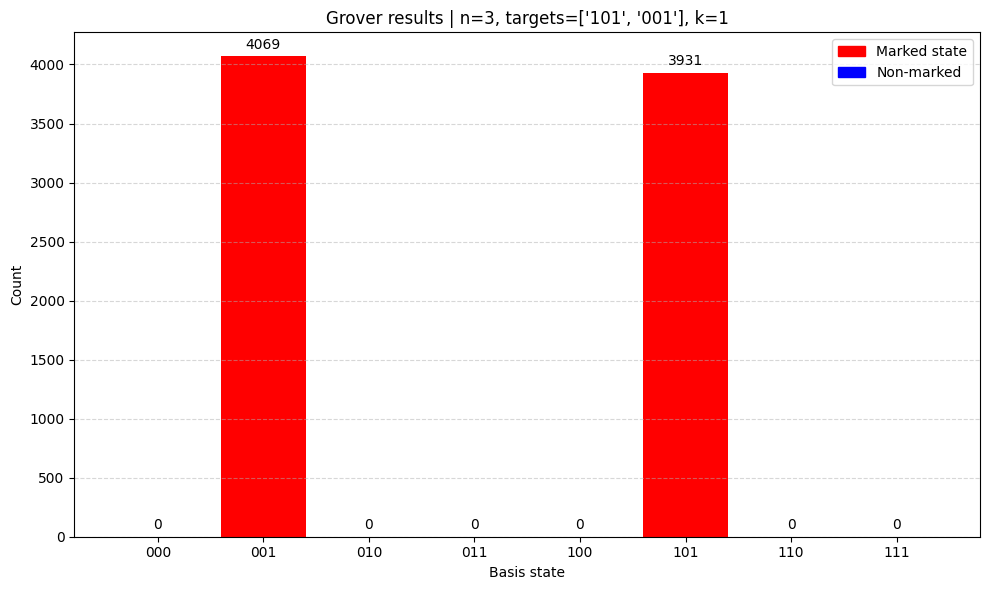

In [90]:
print('Example 1: n=3, N=8, M=2')
result1 = run_grover(n=3, marked_states=['101','001'])

Example 2: n=3, N=8, M=5
Circuit:
     ┌───┐ init ┌───────────────┐┌───────────┐ meas ┌─┐      
q_0: ┤ H ├──░───┤0              ├┤0          ├──░───┤M├──────
     ├───┤  ░   │               ││           │  ░   └╥┘┌─┐   
q_1: ┤ H ├──░───┤1 Phase oracle ├┤1 Diffuser ├──░────╫─┤M├───
     ├───┤  ░   │               ││           │  ░    ║ └╥┘┌─┐
q_2: ┤ H ├──░───┤2              ├┤2          ├──░────╫──╫─┤M├
     └───┘  ░   └───────────────┘└───────────┘  ░    ║  ║ └╥┘
c: 3/════════════════════════════════════════════════╩══╩══╩═
                                                     0  1  2 

────────────────────────────────────────────────────
  Qubits            : 3
  Search space N    : 8
  Solutions M       : 2 → ['101', '001']
  Grover iterations : 1
  Shots             : 8000
────────────────────────────────────────────────────
  Success rate      : 100.00% (8000/8000)
  Classical baseline: 25.00%
  Effective speedup : 4.0×
────────────────────────────────────────────────────
  Top meas

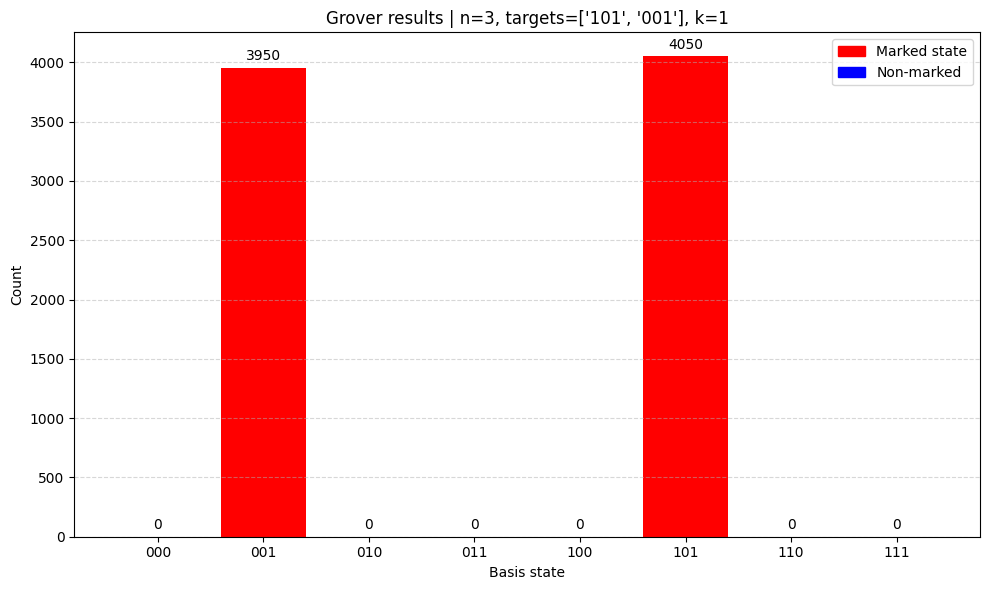

In [96]:
print('Example 2: n=3, N=8, M=5')
result2 = run_grover(n=3, marked_states=['101','001'])

Example 3: n=4, N=16, M=2
Circuit:
     ┌───┐ init ┌───────────────┐┌───────────┐ iter 1 ┌───────────────┐┌───────────┐ meas ┌─┐         
q_0: ┤ H ├──░───┤0              ├┤0          ├───░────┤0              ├┤0          ├──░───┤M├─────────
     ├───┤  ░   │               ││           │   ░    │               ││           │  ░   └╥┘┌─┐      
q_1: ┤ H ├──░───┤1              ├┤1          ├───░────┤1              ├┤1          ├──░────╫─┤M├──────
     ├───┤  ░   │  Phase oracle ││  Diffuser │   ░    │  Phase oracle ││  Diffuser │  ░    ║ └╥┘┌─┐   
q_2: ┤ H ├──░───┤2              ├┤2          ├───░────┤2              ├┤2          ├──░────╫──╫─┤M├───
     ├───┤  ░   │               ││           │   ░    │               ││           │  ░    ║  ║ └╥┘┌─┐
q_3: ┤ H ├──░───┤3              ├┤3          ├───░────┤3              ├┤3          ├──░────╫──╫──╫─┤M├
     └───┘  ░   └───────────────┘└───────────┘   ░    └───────────────┘└───────────┘  ░    ║  ║  ║ └╥┘
c: 4/═════════════════════════════════

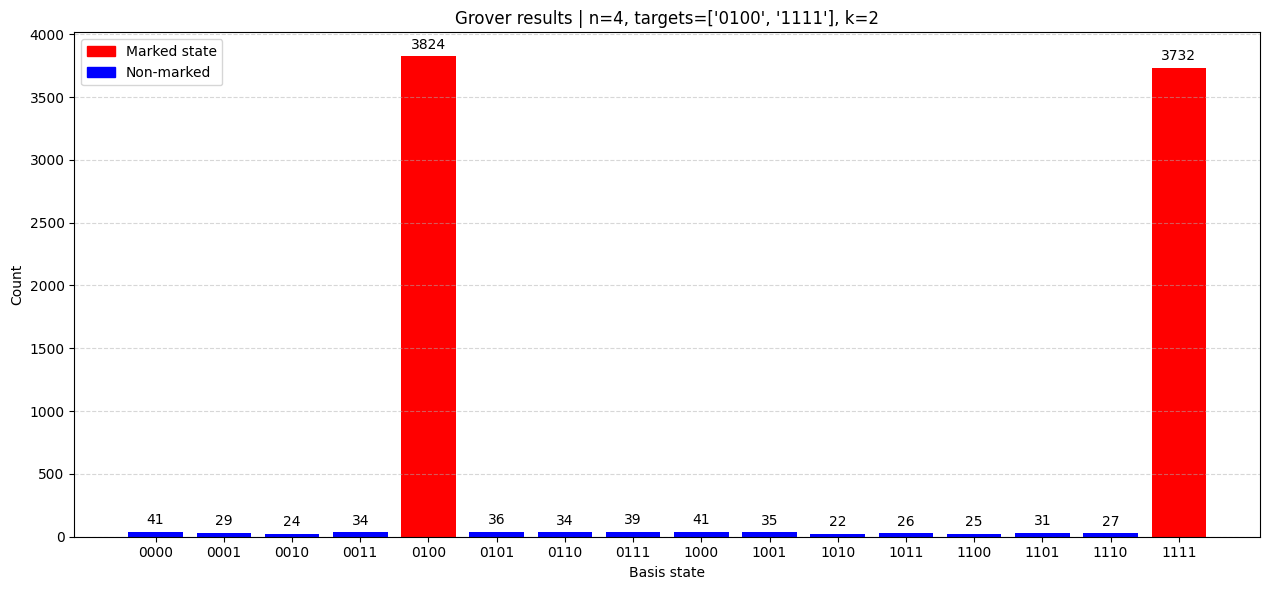

In [98]:
print('Example 3: n=4, N=16, M=2')
result3 = run_grover(n=4, marked_states=['0100','1111'])

----------------------------------------------------

$G = U \cdot R$

where $U$ is the phase oracle(coin) and $R$ is the diffuser(shift).

In [102]:
def quantum_walk_step(n: int, marked_states: list[str]) -> QuantumCircuit:
    
    qc = QuantumCircuit(n, name='Quantum Walk Step')

    # Step 1: Diffusion (The "shift" on the complete graph)
    diffuser_gate = diffuser(n).to_gate()
    qc.append(diffuser_gate, range(n))
    
    # Step 2: Oracle (Mark the target vertices)
    oracle_gate = phase_oracle(marked_states).to_gate()
    qc.append(oracle_gate, range(n))
    
    return qc

In [104]:
def quantum_walk_circuit(
    n: int,
    marked_states: list[str],
    steps: int | None = None,
) -> tuple[QuantumCircuit, int]:

    if steps is None:
        steps = optimal_iterations(n, len(marked_states))
    
    qr = QuantumRegister(n, 'q')
    cr = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(qr, cr)
    
    # Initial state: uniform superposition over all vertices
    qc.h(range(n))
    qc.barrier(label='init')
    
    # Walk steps
    walk_step = quantum_walk_step(n, marked_states)
    
    for i in range(steps):
        qc.append(walk_step, range(n))
        if i < steps - 1:
            qc.barrier(label=f'walk step {i+1}')
    
    # Measure
    qc.barrier(label='meas')
    qc.measure(range(n), range(n))
    
    return qc, steps

In [106]:
def visualize_quantum_walk(n: int, marked_states: list[str], steps: int = None):

    if steps is None:
        steps = optimal_iterations(n, len(marked_states))
    
    # Build and run the quantum walk circuit
    qc, _ = quantum_walk_circuit(n, marked_states, steps)
    
    # Use the same simulation setup
    compiled = transpile(qc, SIM)
    counts = SIM.run(compiled, shots=SHOTS).result().get_counts()
    
    # Convert to probability distribution
    N = 2**n
    all_states = [format(i, f'0{n}b') for i in range(N)]
    probs = [counts.get(state, 0) / SHOTS for state in all_states]
    
    # Plot the distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    bar_colors = []
    for state, prob in zip(all_states, probs):
        if state in marked_states:
            bar_colors.append('red')
        else:
            # Blue intensity based on probability
            intensity = min(0.9, prob * 10)
            bar_colors.append((0, 0, intensity))
    
    bars = ax1.bar(all_states, probs, color=bar_colors, alpha=0.8)
    ax1.set_title(f'Quantum Walk on Complete Graph K_{N}\n{steps} steps, marked: {marked_states}')
    ax1.set_xlabel('Vertex')
    ax1.set_ylabel('Probability')
    ax1.set_ylim(0, max(probs) * 1.2 if max(probs) > 0 else 0.1)
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on top of bars
    for bar, prob in zip(bars, probs):
        if prob > 0.01:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{prob:.2f}', ha='center', va='bottom', fontsize=8)

    
    # Graph visualization (for small N)
    if N <= 32:
        import networkx as nx
        G = nx.complete_graph(N)
        pos = nx.circular_layout(G)
        
        # Node colors based on probability and marked status
        node_colors = []
        for i, state in enumerate(all_states):
            prob = probs[i]
            if state in marked_states:
                node_colors.append('red')
            else:
                if prob > 0:
                    # Intensity based on probability
                    intensity = min(0.9, prob * 10)
                    node_colors.append((0, 0, intensity))
                else:
                    node_colors.append('lightgray')
        
        nx.draw(G, pos, ax=ax2, 
                node_color=node_colors, 
                node_size=500, 
                with_labels=True, 
                labels={i: all_states[i] for i in range(N)},
                font_size=8, 
                font_color='white',
                edge_color='lightgray',
                alpha=0.9)
        ax2.set_title('Complete Graph K_{}'.format(N))
    else:
        ax2.text(0.5, 0.5, f'N={N} too large for graph visualization\nShowing distribution only',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

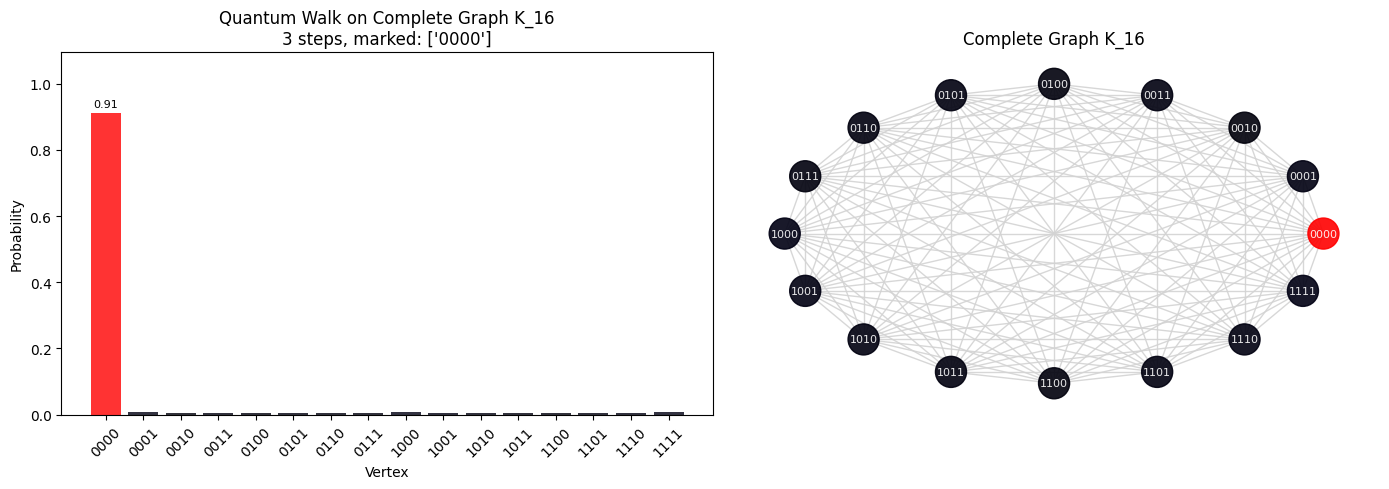

In [110]:
visualize_quantum_walk(n=4, marked_states=['0000'])

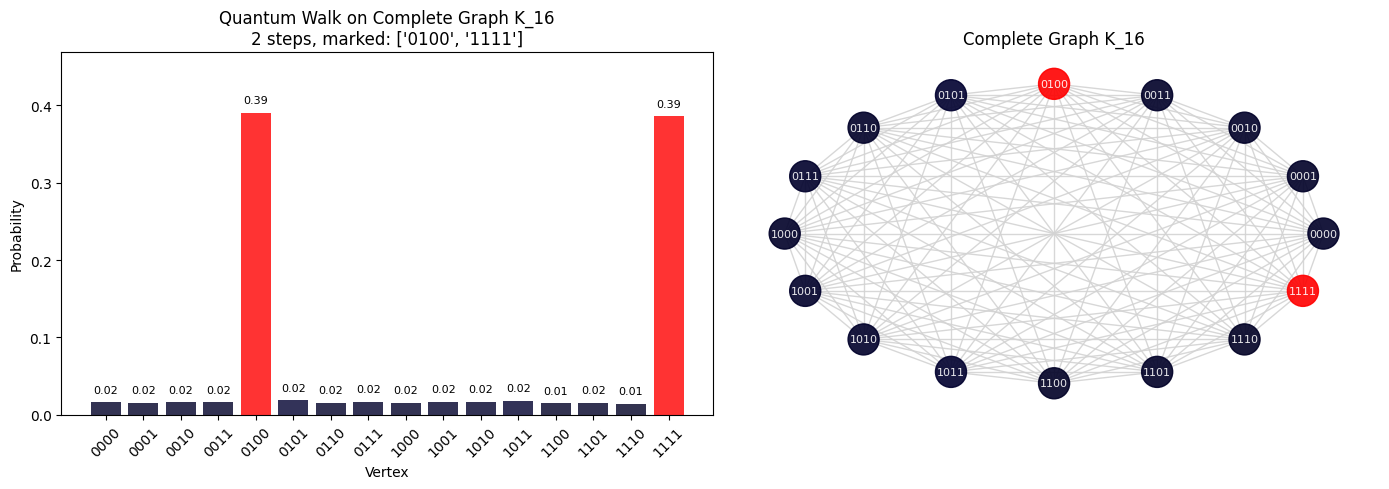

In [112]:
visualize_quantum_walk(n=4, marked_states=['0100','1111'])

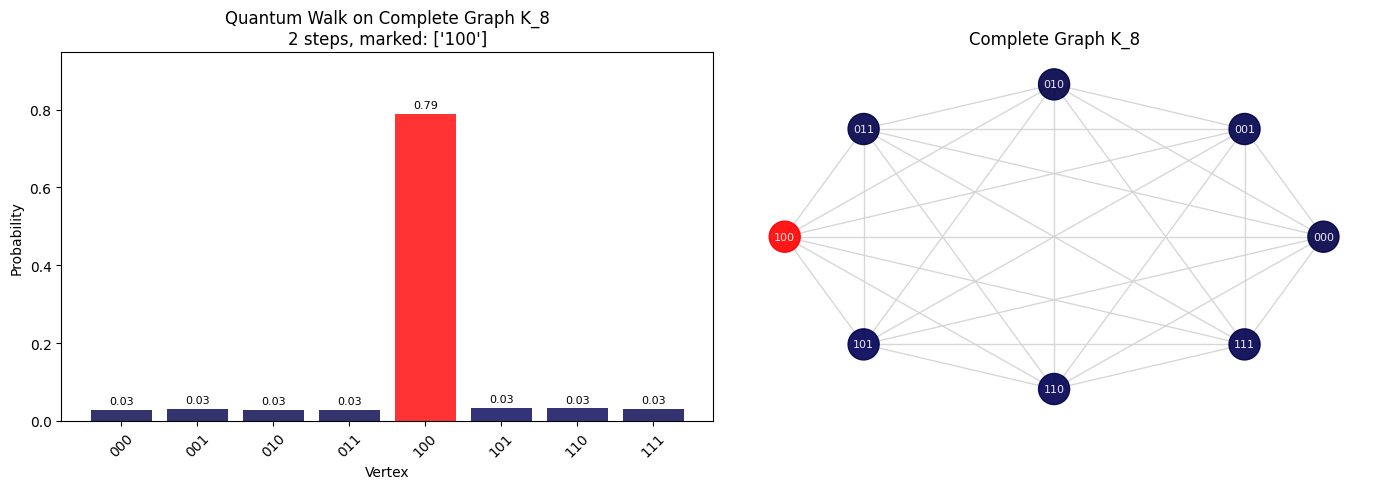

In [114]:
visualize_quantum_walk(n=3, marked_states=['100'])

* #### When your problem has a spatial structure or a graph that is not fully connected like the graph below, you have to use the more general case (quantum walk) rather than Grover's search

<center style="white-space: nowrap;">
    <img src="./cluster.png" width="500" style="display: inline-block;">
</center>